In [ ]:
# =========================================
# Setup: libs
# =========================================
!pip -q install torch torchvision scikit-learn

import os, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

import torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import vgg16, VGG16_Weights
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
# =========================================
# (Opcional) Monte seu Drive e aponte para a pasta do dataset
# from google.colab import drive
# drive.mount('/content/drive')
DATA_ROOT = Path('/home/gustavom/Documents/Orange/Brain Tumor MRI Dataset/Training')  # ajuste o caminho
# =========================================

# Use a pasta local "eye_diseases" por padrão (suba/extraia ela no Colab)
# DATA_ROOT = Path("eye_diseases")  # EXPECT: subpastas por classe

# Caso você já tenha:
# eye_diseases/train/<classes> e eye_diseases/validation/<classes>, será usado diretamente.
use_predefined_split = (DATA_ROOT/"train").exists() and (DATA_ROOT/"validation").exists()

# Transforms (padronização ImageNet + leve aumento no treino)
IMAGENET_MEAN, IMAGENET_STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

if use_predefined_split:
    train_ds = datasets.ImageFolder(DATA_ROOT/"train", transform=train_tfms)
    val_ds   = datasets.ImageFolder(DATA_ROOT/"validation", transform=val_tfms)
    class_names = train_ds.classes
else:
    # Uma única pasta com as classes dentro -> split estratificado 80/20
    full_ds_no_tfms = datasets.ImageFolder(DATA_ROOT)  # só para ler rótulos
    class_names = full_ds_no_tfms.classes
    targets = [y for _, y in full_ds_no_tfms.samples]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

    # Dois datasets com transforms diferentes reusando os mesmos arquivos
    train_ds_all = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
    val_ds_all   = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)

    train_ds = Subset(train_ds_all, train_idx)
    val_ds   = Subset(val_ds_all,   val_idx)

print("Classes:", class_names)

# DataLoaders
batch_size = 32
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers)


Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [ ]:
# =========================================
# Modelo: VGG16 pré-treinada + cabeça nova (4 classes)
# =========================================
weights = VGG16_Weights.IMAGENET1K_V1
model = vgg16(weights=weights)

# Congela extrator de features para treinamento rápido/estável
for p in model.features.parameters():
    p.requires_grad = False

# Troca a última FC para 4 classes
num_classes = 4
in_feats = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_feats, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()  # se houver forte desbalanceamento, considere weights
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# =========================================
# Utilitários
# =========================================
def run_epoch(model, loader, train=True):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        if train: optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        if train:
            loss.backward(); optimizer.step()
        preds = logits.argmax(1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())
    avg_loss = total_loss/total
    acc = total_correct/total
    y_true = np.concatenate(all_targets); y_pred = np.concatenate(all_preds)
    f1 = f1_score(y_true, y_pred, average='macro')
    return avg_loss, acc, f1, y_true, y_pred

def plot_curve(hist, k1, k2, title, ylab):
    plt.figure(figsize=(6,4))
    plt.plot(hist[k1], label=k1)
    plt.plot(hist[k2], label=k2)
    plt.xlabel("epoch"); plt.ylabel(ylab); plt.title(title); plt.legend(); plt.show()

def plot_cm(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize: cm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    import itertools
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest'); plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes)); plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    fmt = ".2f" if normalize else "d"; thresh = cm.max()/2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 57.1MB/s]


[1/3] train_loss=0.7574 acc=0.7403 | val_loss=0.5929 acc=0.8235 f1=0.8248
[2/3] train_loss=0.5231 acc=0.8396 | val_loss=0.3633 acc=0.8614 f1=0.8607
[3/3] train_loss=0.4960 acc=0.8458 | val_loss=0.4223 acc=0.8768 f1=0.8710


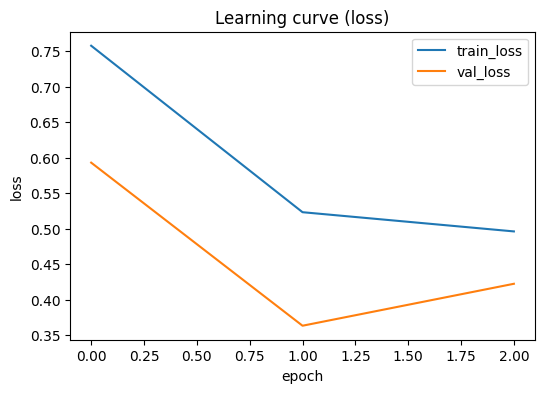

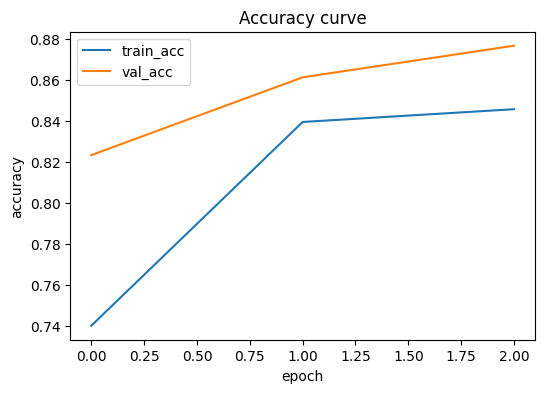


Validation metrics:
Accuracy: 0.8768 | F1 (macro): 0.8710

Classification report:
                       precision    recall  f1-score   support

            cataract       0.88      0.90      0.89       208
diabetic_retinopathy       1.00      1.00      1.00       220
            glaucoma       0.84      0.66      0.74       201
              normal       0.79      0.93      0.86       215

            accuracy                           0.88       844
           macro avg       0.88      0.87      0.87       844
        weighted avg       0.88      0.88      0.87       844



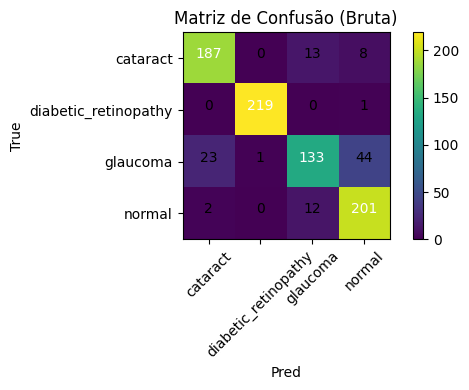

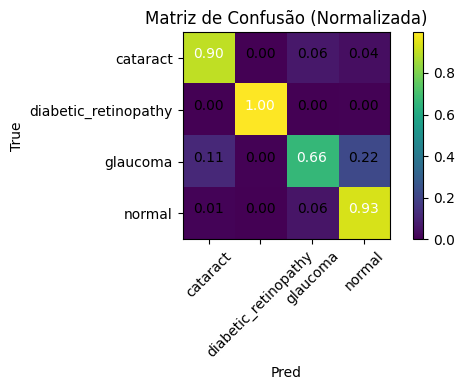

In [ ]:
# =========================================
# Treinamento (curto)
# =========================================
EPOCHS = 3  # aumente para 5–10 para melhor desempenho se tiver GPU
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}

for e in range(1, EPOCHS+1):
    tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, train=True)
    va_loss, va_acc, va_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc); history["val_f1"].append(va_f1)
    print(f"[{e}/{EPOCHS}] train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

# Curvas
plot_curve(history, "train_loss", "val_loss", "Learning curve (loss)", "loss")
plot_curve(history, "train_acc",  "val_acc",  "Accuracy curve",       "accuracy")

# Métricas finais
print("\nValidation metrics:")
print(f"Accuracy: {history['val_acc'][-1]:.4f} | F1 (macro): {history['val_f1'][-1]:.4f}")
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names, normalize=False, title="Matriz de Confusão (Bruta)")
plot_cm(cm, class_names, normalize=True,  title="Matriz de Confusão (Normalizada)")